<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/10_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
%pip install statsmodels


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
#Cargamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

In [29]:
df=pd.read_csv('DataAnalytics.csv')
df.head(10)

,Administrador,Usuario,botón correcto,tiempo de interacción,mini juego,número de interacción,color presionado,dificultad,fecha,Juego,auto push,tiempo de lección,tiempo de sesión
0,nicolas,nicolas,1.0,5.399169,Despegue,1.0,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,0.0,0.0,0.0
1,nicolas,nicolas,0.0,1.283400,Despegue,2.0,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,0.0,0.0
2,nicolas,nicolas,1.0,2.700226,Despegue,3.0,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,0.0,0.0,0.0
3,nicolas,nicolas,0.0,3.050262,Despegue,4.0,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,0.0,0.0
4,nicolas,nicolas,0.0,4.750256,Despegue,5.0,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,0.0,0.0
5,nicolas,nicolas,0.0,7.400463,Despegue,6.0,green,Episodio 1,25/01/2024 09:27:01 a. m.,Astro,0.0,0.0,0.0
6,nicolas,nicolas,0.0,13.167350,Despegue,7.0,green,Episodio 1,25/01/2024 09:27:07 a. m.,Astro,0.0,0.0,0.0
7,nicolas,nicolas,1.0,22.467780,Despegue,8.0,yellow,Episodio 1,25/01/2024 09:27:16 a. m.,Astro,0.0,0.0,0.0
8,nicolas,nicolas,0.0,14.517180,Despegue,9.0,green,Episodio 1,25/01/2024 09:27:37 a. m.,Astro,0.0,0.0,0.0
9,nicolas,nicolas,0.0,15.617350,Despegue,10.0,blue,Episodio 1,25/01/2024 09:27:38 a. m.,Astro,0.0,0.0,0.0


# Limpieza de Nulos

In [30]:
df =df.fillna(method="bfill")
df =df.fillna(method="ffill")
df =df.fillna(method="bfill")
df.isnull().sum()

/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_52760/1006068301.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df =df.fillna(method="bfill")
/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_52760/1006068301.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df =df.fillna(method="ffill")
/var/folders/yg/xy4x70qj5dsfw9snfhl6938r0000gp/T/ipykernel_52760/1006068301.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df =df.fillna(method="bfill")


Administrador            0
Usuario                  0
botón correcto           0
tiempo de interacción    0
mini juego               0
número de interacción    0
color presionado         0
dificultad               0
fecha                    0
Juego                    0
auto push                0
tiempo de lección        0
tiempo de sesión         0
dtype: int64

# Limpieza de Outliers

In [31]:
cuantitativas=df.select_dtypes(include=["float64","int64","float","int"])
cualitativas=df.select_dtypes(include=["object","datetime","category"])
y=cuantitativas

percentile25=y.quantile(0.25)
percentile75=y.quantile(0.75)
iqr= percentile75-percentile25

Limite_Superior_iqr= percentile75+1.5*iqr
Limite_Inferior_iqr= percentile25-1.5*iqr
iqr=cuantitativas[(y<=Limite_Superior_iqr)&y>=(Limite_Inferior_iqr)]
iqr2=iqr.fillna(round(iqr.mean(),1))
df=pd.concat([cualitativas,iqr2],axis=1)
df.head(5)

,Administrador,Usuario,mini juego,color presionado,dificultad,fecha,Juego,botón correcto,tiempo de interacción,número de interacción,auto push,tiempo de lección,tiempo de sesión
0,nicolas,nicolas,Despegue,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,1.0,5.399169,1.0,0.0,0.0,0.0
1,nicolas,nicolas,Despegue,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,1.283400,2.0,0.0,0.0,0.0
2,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,1.0,2.700226,3.0,0.0,0.0,0.0
3,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,3.050262,4.0,0.0,0.0,0.0
4,nicolas,nicolas,Despegue,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,4.750256,5.0,0.0,0.0,0.0


# Boxplots

<Axes: title={'center': 'botón correcto'}, xlabel='Juego'>

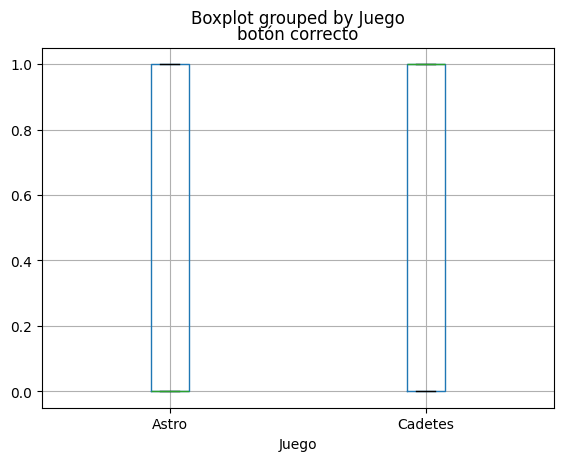

In [32]:
#botón correcto
df.boxplot("botón correcto", by= "Juego")

<Axes: title={'center': 'tiempo de interacción'}, xlabel='Juego'>

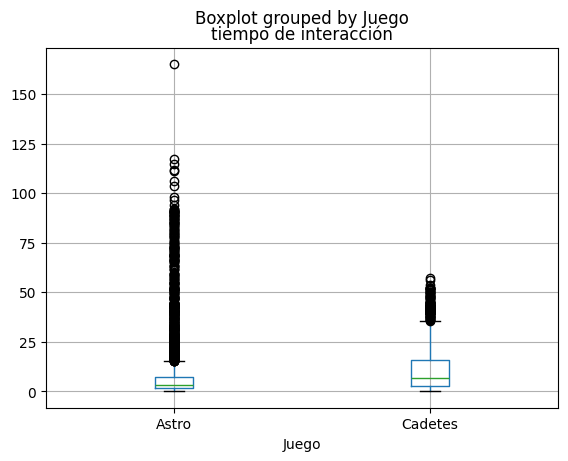

In [33]:
#tiempo de interacción
df.boxplot("tiempo de interacción", by= "Juego")

<Axes: title={'center': 'número de interacción'}, xlabel='Juego'>

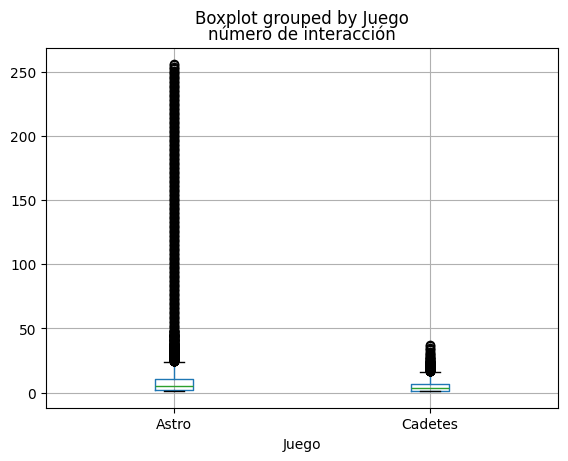

In [34]:
#número de interacción
df.boxplot("número de interacción", by= "Juego")

<Axes: title={'center': 'auto push'}, xlabel='Juego'>

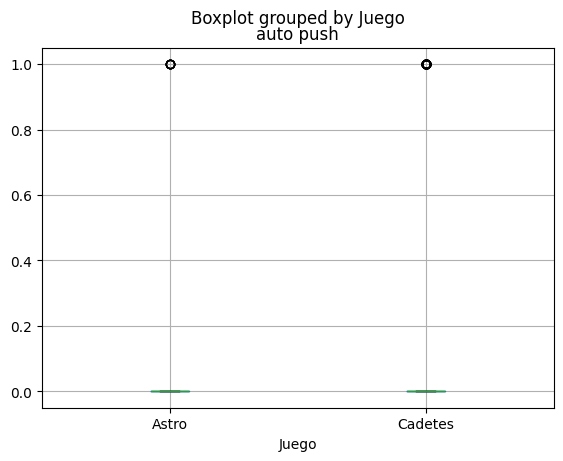

In [35]:
#auto push
df.boxplot("auto push", by= "Juego")

<Axes: title={'center': 'tiempo de lección'}, xlabel='Juego'>

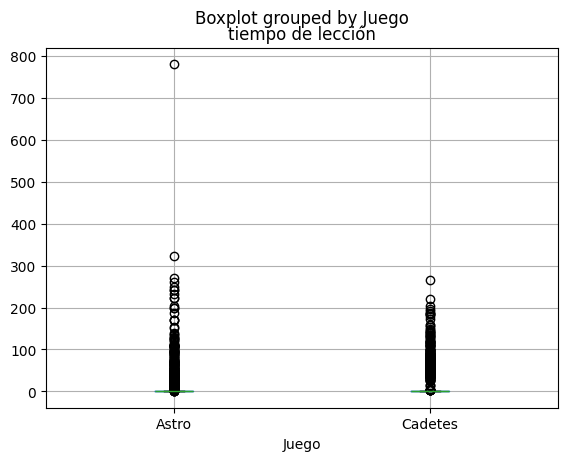

In [36]:
#tiempo de lección
df.boxplot("tiempo de lección", by= "Juego")

<Axes: title={'center': 'tiempo de sesión'}, xlabel='Juego'>

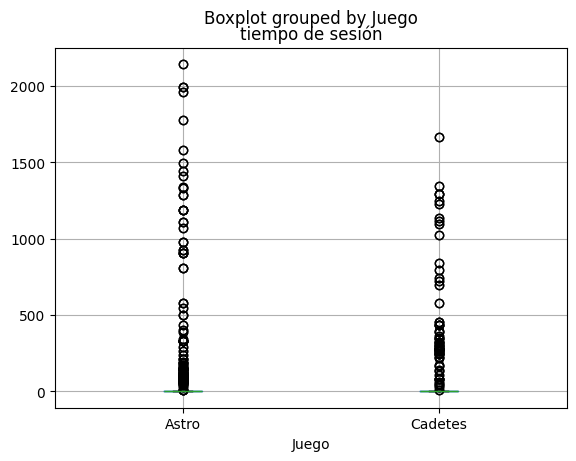

In [37]:
#tiempo de sesión
df.boxplot("tiempo de sesión", by= "Juego")

# Análisis de varianza

Cambio de nombre de variables

In [55]:
df = df.rename(columns={'botón correcto': 'boton_correcto'})
df = df.rename(columns={'tiempo de interacción': 'tiempo_interaccion'})
df = df.rename(columns={'número de interacción': 'numero_interaccion'})
df = df.rename(columns={'auto push': 'auto_push'})
df = df.rename(columns={'tiempo de lección': 'tiempo_leccion'})
df = df.rename(columns={'tiempo de sesión': 'tiempo_sesion'})

Categorías de la variable (Juego)

In [56]:
grupos=pd.unique(df['Juego'].values)
grupos

array(['Astro', 'Cadetes'], dtype=object)

**SCIPY ONEWAY (ANOVA)**

In [57]:
#boton_correcto
Fare_1 = df['boton_correcto'][df['Juego'] == 'Astro']
Fare_2 = df['boton_correcto'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)


Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=15.445823782294877, pvalue=8.588147189897759e-05)


In [58]:
#tiempo_interaccion
Fare_1 = df['tiempo_interaccion'][df['Juego'] == 'Astro']
Fare_2 = df['tiempo_interaccion'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)

Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=30.613003824401495, pvalue=3.2861516817070094e-08)


In [59]:
#numero_interaccion
Fare_1 = df['numero_interaccion'][df['Juego'] == 'Astro']
Fare_2 = df['numero_interaccion'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)

Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=148.53944852095077, pvalue=9.235165100191986e-34)


In [60]:
#auto_push
Fare_1 = df['auto_push'][df['Juego'] == 'Astro']
Fare_2 = df['auto_push'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)

Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=95.89962047495608, pvalue=1.7958000076851027e-22)


In [61]:
#tiempo_leccion
Fare_1 = df['tiempo_leccion'][df['Juego'] == 'Astro']
Fare_2 = df['tiempo_leccion'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)

Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=30.039718218271375, pvalue=4.409444661320947e-08)


In [62]:
#tiempo_sesion
Fare_1 = df['tiempo_sesion'][df['Juego'] == 'Astro']
Fare_2 = df['tiempo_sesion'][df['Juego'] == 'Cadetes']
anova= stats.f_oneway(Fare_1, Fare_2)
print("Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)")
print(anova)

Scipy Oneway (ANOVA): (p-value < 0.05 se rechaza y p-value > 0.05 es que influye)
F_onewayResult(statistic=0.7807617905689256, pvalue=0.37694448836418826)


**STATESMODELS (ANOVA)**

In [63]:
#boton_correcto
mod = ols('boton_correcto ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('boton_correcto ~ Juego + tiempo_interaccion + Juego:tiempo_interaccion', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df       sum_sq   mean_sq          F    PR(>F)
Juego        1.0     3.848873  3.848873  15.445824  0.000086
Residual  5863.0  1460.973634  0.249185        NaN       NaN

MANOVA
                              df       sum_sq    mean_sq          F  \
Juego                        1.0     3.848873   3.848873  15.745192   
tiempo_interaccion           1.0    17.076269  17.076269  69.856590   
Juego:tiempo_interaccion     1.0    11.190557  11.190557  45.778978   
Residual                  5861.0  1432.706808   0.244448        NaN   

                                PR(>F)  
Juego                     7.333721e-05  
tiempo_interaccion        7.886892e-17  
Juego:tiempo_interaccion  1.452467e-11  
Residual                           NaN  


In [64]:
#tiempo_interaccion
mod = ols('tiempo_interaccion ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('tiempo_interaccion ~ Juego + numero_interaccion + Juego:numero_interaccion', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df        sum_sq      mean_sq          F        PR(>F)
Juego        1.0  6.413266e+03  6413.265935  30.613004  3.286152e-08
Residual  5863.0  1.228268e+06   209.494827        NaN           NaN

MANOVA
                              df         sum_sq        mean_sq            F  \
Juego                        1.0    6413.265935    6413.265935    46.064807   
numero_interaccion           1.0  410867.741224  410867.741224  2951.155231   
Juego:numero_interaccion     1.0    1416.299316    1416.299316    10.172907   
Residual                  5861.0  815984.129128     139.222680          NaN   

                                PR(>F)  
Juego                     1.256707e-11  
numero_interaccion        0.000000e+00  
Juego:numero_interaccion  1.432701e-03  
Residual                           NaN  


In [65]:
#numero_interaccion
mod = ols('numero_interaccion ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('numero_interaccion ~ Juego + auto_push + Juego:auto_push', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df        sum_sq        mean_sq           F        PR(>F)
Juego        1.0  1.318204e+05  131820.389467  148.539449  9.235165e-34
Residual  5863.0  5.203082e+06     887.443644         NaN           NaN

MANOVA
                     df        sum_sq        mean_sq           F        PR(>F)
Juego               1.0  1.318204e+05  131820.389467  148.524022  9.308295e-34
auto_push           1.0  4.362741e+01      43.627406    0.049156  8.245468e-01
Juego:auto_push     1.0  1.191011e+03    1191.011248    1.341930  2.467410e-01
Residual         5861.0  5.201847e+06     887.535821         NaN           NaN


In [66]:
#auto_push
mod = ols('auto_push ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('auto_push ~ Juego + tiempo_leccion + Juego:tiempo_leccion', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df     sum_sq   mean_sq         F        PR(>F)
Juego        1.0   1.081671  1.081671  95.89962  1.795800e-22
Residual  5863.0  66.129924  0.011279       NaN           NaN

MANOVA
                          df     sum_sq   mean_sq          F        PR(>F)
Juego                    1.0   1.081671  1.081671  96.038999  1.675845e-22
tiempo_leccion           1.0   0.084061  0.084061   7.463598  6.314764e-03
Juego:tiempo_leccion     1.0   0.034437  0.034437   3.057552  8.041502e-02
Residual              5861.0  66.011426  0.011263        NaN           NaN


In [67]:
#tiempo_leccion
mod = ols('tiempo_leccion ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('tiempo_leccion ~ Juego + tiempo_sesion + Juego:tiempo_sesion', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df        sum_sq       mean_sq          F        PR(>F)
Juego        1.0  1.964532e+04  19645.317260  30.039718  4.409445e-08
Residual  5863.0  3.834273e+06    653.978081        NaN           NaN

MANOVA
                         df        sum_sq        mean_sq           F  \
Juego                   1.0  1.964532e+04   19645.317260   30.978514   
tiempo_sesion           1.0  1.066014e+05  106601.366535  168.098680   
Juego:tiempo_sesion     1.0  1.086358e+04   10863.579204   17.130675   
Residual             5861.0  3.716809e+06     634.159451         NaN   

                           PR(>F)  
Juego                2.724712e-08  
tiempo_sesion        6.371309e-38  
Juego:tiempo_sesion  3.538342e-05  
Residual                      NaN  


In [68]:
#tiempo_sesion
mod = ols('tiempo_sesion ~ Juego', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print("ANOVA")
print(anova_table)
mod= ols('tiempo_sesion ~ Juego + boton_correcto + Juego:boton_correcto', data=df).fit()
manova_table=sm.stats.anova_lm(mod, typ=1)
print("")
print("MANOVA")
print (manova_table)

ANOVA
              df        sum_sq       mean_sq         F    PR(>F)
Juego        1.0  1.825828e+04  18258.279489  0.780762  0.376944
Residual  5863.0  1.371075e+08  23385.211354       NaN       NaN

MANOVA
                          df        sum_sq        mean_sq          F    PR(>F)
Juego                    1.0  1.825828e+04   18258.279489   0.783187  0.376204
boton_correcto           1.0  4.411349e+05  441134.897910  18.922447  0.000014
Juego:boton_correcto     1.0  3.013838e+04   30138.380175   1.292783  0.255582
Residual              5861.0  1.366362e+08   23312.782953        NaN       NaN
